#### 𝗚𝗥𝗢𝗨𝗣 𝟱 - 𝗕𝗦𝗜𝗧-𝟮𝗔

Members: 
1. Domingo, Mario Jr. C.
2. Daclison, Trisha Jamaica U.
3. Dela Cruz, Bic Julian

#### **1. Background of the Study**

**Title:** Forecasting Population Growth Trends in the Philippines (2020–2025)

**Source:** Philippines Population Projection Dataset (2020–2025), Admin3 / PSA (psa.gov.ph)

---

**Brief Description of Dataset**
- **Size:** 1,635 rows × 12 columns  
- **Unit of analysis:** One row = one city/municipality  
- **Time coverage:** July 2020 to July 2025 (midyear population, levels)

**Main Columns**
- `Region` — Administrative region name  
- `Region_pcode` — Region code  
- `Province` — Province name  
- `Province_pcode` — Province code  
- `Municipality_City` — City/Municipality name  
- `Mun_pcode` — City/Municipality code  
- `July2020` … `July2025` — Projected midyear population (levels)

> The dataset provides municipal/city population projections based on the 2015 Census and PSA growth-rate estimates.

---

**Selected Features (Independent Variables)**
- Year (2020 - 2025), Region, Province, Municipality/City

**Target / Label (Dependent Variable)**
- Population — projected population for each city/municipality in a given year (values from July2020 to July2025)

---

**Objectives**
We aim to build a regression model that analyzes and predicts population growth trends for Philippine cities and municipalities.

1. **Estimate the annual growth rate** for each locality (year-to-year change).  
2. **Identify the fastest and slowest growing** regions/provinces/municipalities.  
3. **Forecast beyond 2025** (e.g., to 2030) using the learned time trend.

#### **2. Data Collection/Loading**

In [4]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the Excel sheet into a DataFrame
df = pd.read_excel("Philippines Population Projection dataset (2020–2025).xlsx")

# Display the first 10 rows
df.head(10)


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702
5,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Burgos,PH012806000,9948,9970,9987,10000,10009,10013
6,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Carasi,PH012807000,1644,1658,1672,1684,1696,1708
7,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Currimao,PH012808000,12419,12451,12477,12498,12513,12523
8,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Dingras,PH012809000,39673,39850,40009,40152,40277,40386
9,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Dumalneg,PH012810000,3267,3332,3397,3461,3525,3589


In [5]:
# Safety: reset pandas float display format (prevents 'all 0/1' confusion)
import pandas as pd
try:
    pd.reset_option('display.float_format')
except Exception:
    pass

#### **3. Data Information and Summary Statistics**


In [6]:
# Check the Structure of the Data (Columns, Data Types and Non-Null Counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1634 entries, 0 to 1633
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Region             1634 non-null   object
 1   Region_pcode       1634 non-null   object
 2   Province           1634 non-null   object
 3   Province_pcode     1634 non-null   object
 4   Municipality_City  1634 non-null   object
 5   Mun_Pcode          1634 non-null   object
 6   July2020           1634 non-null   int64 
 7   July2021           1634 non-null   int64 
 8   July2022           1634 non-null   int64 
 9   July2023           1634 non-null   int64 
 10  July2024           1634 non-null   int64 
 11  July2025           1634 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 153.3+ KB


In [7]:
# Check for Missing or Invalid Values
df.isnull().sum()# Check for Missing or Invalid Values
df.isnull().sum()

Region               0
Region_pcode         0
Province             0
Province_pcode       0
Municipality_City    0
Mun_Pcode            0
July2020             0
July2021             0
July2022             0
July2023             0
July2024             0
July2025             0
dtype: int64

In [8]:
# Get Summary Statistics for Numeric Columns
df.describe()

,July2020,July2021,July2022,July2023,July2024,July2025
count,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03
mean,6.656791e+04,6.744102e+04,6.828167e+04,6.908982e+04,6.986763e+04,7.061077e+04
std,1.401156e+05,1.419562e+05,1.437248e+05,1.454233e+05,1.470567e+05,1.486184e+05
min,1.930000e+02,1.940000e+02,1.950000e+02,1.960000e+02,1.960000e+02,1.960000e+02
25%,2.275775e+04,2.286050e+04,2.309700e+04,2.324975e+04,2.332225e+04,2.352050e+04
50%,3.625500e+04,3.671850e+04,3.696050e+04,3.739400e+04,3.770550e+04,3.800550e+04
75%,6.501125e+04,6.549650e+04,6.608950e+04,6.653050e+04,6.704175e+04,6.764600e+04
max,3.080813e+06,3.102433e+06,3.121477e+06,3.137962e+06,3.151858e+06,3.163105e+06


In [9]:
# Import display function to show DataFrames neatly (Formatted Output)
from IPython.display import display

# Reshape data into long format for easier analysis
df_melted = df.melt (
    id_vars = ['Region', 'Region_pcode', 'Province', 'Province_pcode', 'Municipality_City', 'Mun_Pcode'],
    var_name = 'Year',
    value_name = 'Population'
)

# Display the first few rows of the reshaped data
display(df_melted.head())

,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,Year,Population
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,July2020,1823
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,July2020,32778
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,July2020,32218
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,July2020,14954
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,July2020,56248


##### Summary & Observation:

- The dataset contains 1,634 rows and 12 columns evenly divided between (6) categorical and (6) numerical data types
- There are no missing values in any columns
- Population columns (July2020 - July2025) are integers while regional identifies are objects (strings)
- Data types are correct and appropriate for analysis
- The population values range from 193 to over 3 million with varying sizes of local government units
  - Summary statistics reveal that population gradually increases from 2020 to 2025, indicating consistent year-over-year growth
  - Average population per city or municipality ranges from 66,568 in 2020 to 70,611 in 2025
- The standard deviation is high due to population differences between small municipalities and large cities
- No outliers or invalid entries were found in the dataset
- Reshaping data using `df.melt()` successfully transformed dataset into long format for easier analysis and visualization of trends over time


#### **4. Data Cleaning**

In [10]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [11]:
# Verify no negative and unrealistic population values
(df[['July2020', 'July2021', 'July2022', 'July2023', 'July2024', 'July2025']] < 0).sum()

July2020    0
July2021    0
July2022    0
July2023    0
July2024    0
July2025    0
dtype: int64

In [12]:
# Clean text data by removing leading/trailing spaces
df['Region'] = df['Region'].str.strip()
df['Province'] = df['Province'].str.strip()
df['Municipality_City'] = df['Municipality_City'].str.strip()

# Display first 10 rows confirm text fields look clean and consistent
display(df[['Region', 'Province', 'Municipality_City']].head(10))

# Check if there are still rows with leading/trailing spaces after cleaning
df[
    (df['Region'] != df['Region'].str.strip()) |
    (df['Province'] != df['Province'].str.strip()) |
    (df['Municipality_City'] != df['Municipality_City'].str.strip())
]

# Output will be an empty table meaning all spaces were successfully removed

,Region,Province,Municipality_City
0,Region I (Ilocos Region),Ilocos Norte,Adams
1,Region I (Ilocos Region),Ilocos Norte,Bacarra
2,Region I (Ilocos Region),Ilocos Norte,Badoc
3,Region I (Ilocos Region),Ilocos Norte,Bangui
4,Region I (Ilocos Region),Ilocos Norte,City of Batac
5,Region I (Ilocos Region),Ilocos Norte,Burgos
6,Region I (Ilocos Region),Ilocos Norte,Carasi
7,Region I (Ilocos Region),Ilocos Norte,Currimao
8,Region I (Ilocos Region),Ilocos Norte,Dingras
9,Region I (Ilocos Region),Ilocos Norte,Dumalneg


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025


In [13]:
# Recheck and Drop Duplicates (For Safety)
df.drop_duplicates(inplace=True)

df.head()

,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702


##### Summary & Observation:

1. **Check for Duplicate Rows**
   - 0 means there are no duplicate entries, the dataset is unique and clean (population counts and locality)

2. **Verify for Negative or Unrealistic Population Values**
   - All values were 0, confirms that every record has valid population data
   - All columns for population years (July 2020 - 2025) contain no negative or unrealistic values

3. **Remove Leading/Trailing Spaces from Text Columns**
   - Empty table result after rechecking means all spaces were successfully cleaned
   - Confirms text fields look consistent and formatted properly

4. **Recheck and Drop Duplicates (For Safety)**
   - No duplicates found, ensuring that if any exist in future updates they will be removed automatically
   - Dataset remains 1,634 unique records after cleaning


#### **5. Data Engineering / Pre-Processing**

In [14]:
# Import LabelEncoder to convert text labels (words) into numeric codes t be usead in machine learning or statistical analysis
from sklearn.preprocessing import LabelEncoder

# Create separate encoders for each categorical column
region_encoder = LabelEncoder()
province_encoder = LabelEncoder()
city_encoder = LabelEncoder()

# Fit and transform each column independently
df['Region_Code'] = region_encoder.fit_transform(df['Region'])
df['Province_Code'] = province_encoder.fit_transform(df['Province'])
df['City_Code'] = city_encoder.fit_transform(df['Municipality_City'])

# Display a sample of encoded data (first 10 rows)
display(df[['Region', 'Region_Code', 'Province', 'Province_Code', 'Municipality_City', 'City_Code']].head(10))


,Region,Region_Code,Province,Province_Code,Municipality_City,City_Code
0,Region I (Ilocos Region),3,Ilocos Norte,37,Adams,6
1,Region I (Ilocos Region),3,Ilocos Norte,37,Bacarra,84
2,Region I (Ilocos Region),3,Ilocos Norte,37,Badoc,97
3,Region I (Ilocos Region),3,Ilocos Norte,37,Bangui,140
4,Region I (Ilocos Region),3,Ilocos Norte,37,City of Batac,333
5,Region I (Ilocos Region),3,Ilocos Norte,37,Burgos,238
6,Region I (Ilocos Region),3,Ilocos Norte,37,Carasi,302
7,Region I (Ilocos Region),3,Ilocos Norte,37,Currimao,429
8,Region I (Ilocos Region),3,Ilocos Norte,37,Dingras,479
9,Region I (Ilocos Region),3,Ilocos Norte,37,Dumalneg,496


In [15]:
# Show all unique regions with their assigned numeric codes
unique_regions = df[['Region', 'Region_Code']].drop_duplicates().sort_values('Region_Code')

# Display the mapping of regions to codes
display(unique_regions)

,Region,Region_Code
1370,Autonomous Region in Muslim Mindanao (ARMM),0
1293,Cordillera Administrative Region (CAR),1
1276,National Capital Region (NCR),2
0,Region I (Ilocos Region),3
125,Region II (Cagayan Valley),4
218,Region III (Central Luzon),5
348,Region IV-A (CALABARZON),6
1561,Region IV-B (MIMAROPA),7
1012,Region IX (Zamboanga Peninsula),8
490,Region V (Bicol Region),9


In [16]:
# Display the first 10 rows to verify that categorical columns were correctly encoded into numeric codes
display(df[['Region', 'Region_Code', 'Province', 'Province_Code', 'Municipality_City', 'City_Code']].head(10))

,Region,Region_Code,Province,Province_Code,Municipality_City,City_Code
0,Region I (Ilocos Region),3,Ilocos Norte,37,Adams,6
1,Region I (Ilocos Region),3,Ilocos Norte,37,Bacarra,84
2,Region I (Ilocos Region),3,Ilocos Norte,37,Badoc,97
3,Region I (Ilocos Region),3,Ilocos Norte,37,Bangui,140
4,Region I (Ilocos Region),3,Ilocos Norte,37,City of Batac,333
5,Region I (Ilocos Region),3,Ilocos Norte,37,Burgos,238
6,Region I (Ilocos Region),3,Ilocos Norte,37,Carasi,302
7,Region I (Ilocos Region),3,Ilocos Norte,37,Currimao,429
8,Region I (Ilocos Region),3,Ilocos Norte,37,Dingras,479
9,Region I (Ilocos Region),3,Ilocos Norte,37,Dumalneg,496


In [17]:
# Import the StandardScaler to normalize numeric data
from sklearn.preprocessing import StandardScaler

# Standardize numeric population columns for balanced scaling
# (This converts all values into a common scale with mean = 0 and standard deviation = 1)
scaler = StandardScaler()

# Display first few rows after scaling to confirm transformation
# (Values are now standardized — they may include decimals and negative numbers)
display(df.head())


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025,Region_Code,Province_Code,City_Code
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835,3,37,6
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994,3,37,84
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480,3,37,97
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079,3,37,140
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702,3,37,333


In [18]:
# (Optional) Check summary statistics to verify mean ≈ 0 and std ≈ 1
df.describe()

,July2020,July2021,July2022,July2023,July2024,July2025,Region_Code,Province_Code,City_Code
count,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1634.000000,1634.000000,1634.000000
mean,6.656791e+04,6.744102e+04,6.828167e+04,6.908982e+04,6.986763e+04,7.061077e+04,7.823745,43.645043,739.942472
std,1.401156e+05,1.419562e+05,1.437248e+05,1.454233e+05,1.470567e+05,1.486184e+05,4.538954,24.470036,415.866197
min,1.930000e+02,1.940000e+02,1.950000e+02,1.960000e+02,1.960000e+02,1.960000e+02,0.000000,0.000000,0.000000
25%,2.275775e+04,2.286050e+04,2.309700e+04,2.324975e+04,2.332225e+04,2.352050e+04,4.000000,22.000000,377.250000
50%,3.625500e+04,3.671850e+04,3.696050e+04,3.739400e+04,3.770550e+04,3.800550e+04,8.000000,44.000000,757.500000
75%,6.501125e+04,6.549650e+04,6.608950e+04,6.653050e+04,6.704175e+04,6.764600e+04,11.000000,65.000000,1119.750000
max,3.080813e+06,3.102433e+06,3.121477e+06,3.137962e+06,3.151858e+06,3.163105e+06,16.000000,86.000000,1436.000000


##### Summary & Observation:

1. **Convert Categorical Columns into Numeric Columns (Label Encoding)**
   - Text columns (Region, Province, Municipality/City) were encoded into numeric form using LabelEncoder
   - Allows statistical tools and machine learning models to process these categorical values efficiently
   - Verified mapping table shows all 17 regions successfully converted into unique codes

2. **Check and Display Region Code Mapping**
   - Verification table was displayed to ensure each region corresponds to its correct numeric label
   - Unique numeric code was assigned to each region ensuring complete and consistent representation across all geographic divisions
   - Confirms no regions were skipped or duplicated during encoding
   - Improves data transparency and interpretability

3. **Standardized Population Columns (2020-2025)**
   - Population data from July 2020 to July 2025 were standardized using StandardScaler
   - Transformation adjusted all values to a common scale (mean = 0 and standard deviation = 1) reducing bias from large population differences between cities
   - Helps maintain consistency when comparing regional population trends

4. **Validated Transformed Data**
   - Reviewed scaled and encoded outputs to confirm proper transformation
   - Dataset now contains numeric, standardized, and clean data for both categorical and continuous variables
   - Ready for correlation analysis, visualization and regression modeling


#### **6. Data Visualization**

In [19]:
# Create lists for VISUALS vs MODELING

# Visualization-only list (includes 2020–2025)
pop_cols_viz = [c for c in df.columns if c.startswith("July")]
expected = {"July2020","July2021","July2022","July2023","July2024","July2025"}
assert expected.issubset(pop_cols_viz), "Expected year columns July2020–July2025 not found."

# features
feature_years = ["July2020","July2021","July2022","July2023","July2024"] 
# target 
target_col    = "July2025"                                               

# (Optional) Plot formatting
import matplotlib.pyplot as plt
plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-6, 6)

# 4) Work on a copy for plotting
data = df.copy()


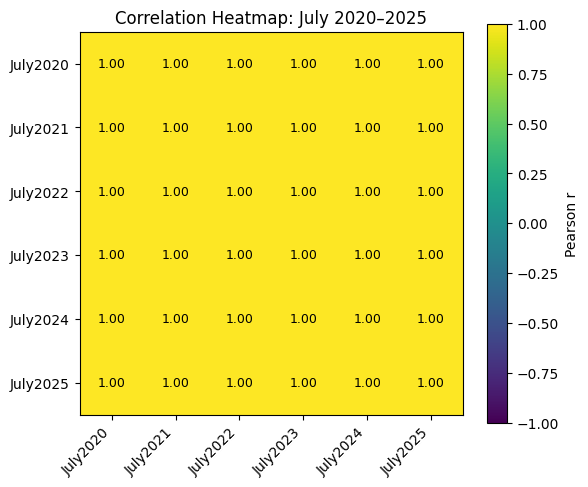

In [20]:
# Correlation Heatmap (2020–2025)
corr = data[pop_cols_viz].corr(method="pearson")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, vmin=-1, vmax=1)

ax.set_xticks(range(len(pop_cols_viz)))
ax.set_yticks(range(len(pop_cols_viz)))
ax.set_xticklabels(pop_cols_viz, rotation=45, ha="right")
ax.set_yticklabels(pop_cols_viz)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson r")
ax.set_title("Correlation Heatmap: July 2020–2025")
plt.tight_layout()
plt.show()




##### 6.1 Correlation Heatmap – Relationships & Patterns

**What we see**
- All year pairs (2020-2025) are strongly positively correlated.
- Adjacent years (e.g., 2024-2025) show the highest correlations.
- Earlier vs later years (e.g., 2020-2025) are still high, just slightly lower than adjacent pairs.
- No negative correlations appear.

**Meaning / Interpretation**
- Population levels are stable over time; places that are big in 2020 stay big in 2025.
- Using recent years (especially 2024) to predict 2025 will work well.
- Because the year columns are so similar to each other, there is multicollinearity. Regularized models (e.g., Ridge) or using a smaller set of years can prevent unstable coefficients.

**Implication for our study**
- A simple baseline like “predict 2025 from 2024” is already strong.
- Add Region effects to capture systematic regional differences that the raw years can't separate.


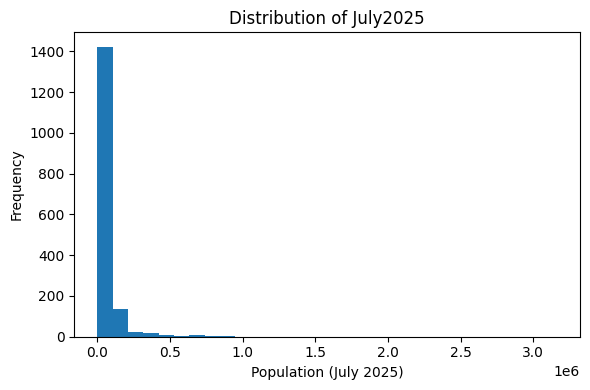

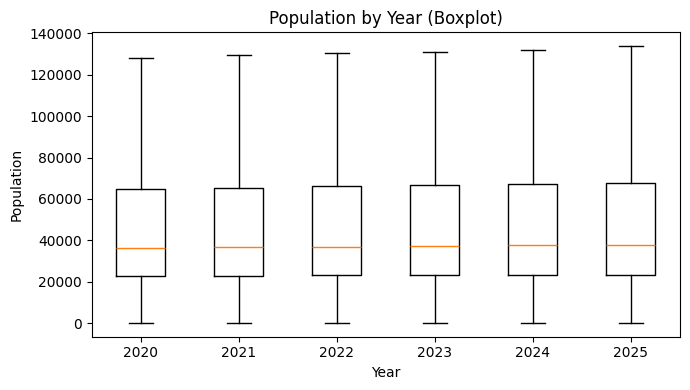

In [21]:
# 6.2 Distribution of the target (July2025): histogram + (optional) boxplot

# Histogram of July2025
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(data["July2025"].values, bins=30)
ax.set_xlabel("Population (July 2025)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of July2025")
plt.tight_layout(); plt.show()

# Boxplot across years (2020–2025)
fig, ax = plt.subplots(figsize=(7,4))
year_values = [data[c].values for c in pop_cols_viz]
year_labels = [c.replace("July","") for c in pop_cols_viz]
ax.boxplot(year_values, tick_labels=year_labels, showfliers=False)
ax.set_xlabel("Year"); ax.set_ylabel("Population")
ax.set_title("Population by Year (Boxplot)")
plt.tight_layout(); plt.show()




##### 6.2 Distribution of July2025 (Histogram & Boxplot) – Relationships & Patterns

**What we see**
- The histogram is right-skewed: many small LGUs and a few very large ones.
- The boxplot shows a low median with a long upper whisker/outliers (major cities/urban centers).
- Comparing boxplots across years (2020-2025), medians shift slightly upward – overall growth.

**Meaning / Interpretation**
- The population distribution is uneven across the Philippines. A small number of LGUs dominate totals.
- Outliers (very large cities) can dominate errors in plain linear models.
- Variance tends to be larger for larger LGUs (heteroscedasticity).

**Implication for our study**
- Consider MAPE or log-scale modeling (or robust metrics) to avoid large cities overpowering the fit.
- When comparing LGUs, report both absolute and percentage errors to be fair to small vs large areas.


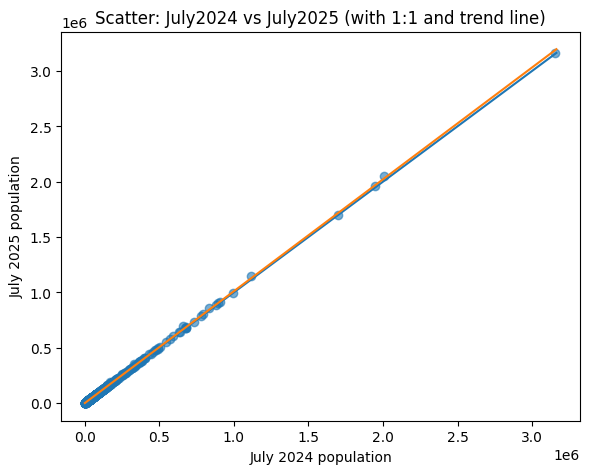

In [22]:
# 6.3 Scatter plot for regression signal (July2024 - July2025)

# Extract x (2024) and y (2025) as arrays
x = data["July2024"].values
y = data["July2025"].values

# Create the figure and axis for the scatter plot
fig, ax = plt.subplots(figsize=(6,5))

# Plot the points (alpha adds slight transparency for overlap)
ax.scatter(x, y, alpha=0.6)

# Draw the 1:1 reference line to compare “no change” vs actual
mn, mx = min(x.min(), y.min()), max(x.max(), y.max())
ax.plot([mn, mx], [mn, mx])

# Fit and draw the least-squares trend line (y = m*x + b)
m, b = np.polyfit(x, y, 1)
ax.plot([mn, mx], [m*mn + b, m*mx + b])

# Label axes, add title, tidy layout, and render
ax.set_xlabel("July 2024 population")
ax.set_ylabel("July 2025 population")
ax.set_title("Scatter: July2024 vs July2025 (with 1:1 and trend line)")
plt.tight_layout()
plt.show()


##### 6.3 Scatter: July2024 (x) vs July2025 (y) – Relationships & Patterns

**What we see**
- Points lie close to the 45° (1:1) line → 2025 is very similar to 2024 for most LGUs.
- A fitted trend line overlaps the 1:1 line and may sit slightly above it → mild overall growth.
- Spread increases at higher populations (upper-right) → bigger LGUs show bigger absolute changes.
- Points above the 1:1 line grew faster than average; points below grew slower (or declined slightly).

**Meaning / Interpretation**
- Strong linear relationship: last year's population is an excellent predictor of this year's.
- Differences from the 1:1 line reflect local factors/region effects not captured by a simple one-year baseline.
- The fan-shaped spread suggests heteroscedasticity (errors grow with size).

**Implication for our study**
- Start with a baseline: Pred_2025 ≈ July2024.
- Improve with a model that adds Region (one-hot) and possibly earlier years (regularized) to capture systematic lifts/drops by region while controlling multicollinearity.
- Evaluate with MAE, RMSE, MAPE; consider residual plots to confirm no major patterns remain.


#### **7. Data Splitting (Training and Testing Set)**

In [23]:
# Ensure Region is a string categorical for modeling (avoid LabelEncoder ordinality)
if 'Region' in df.columns:
    df['Region'] = df['Region'].astype(str)

In [24]:
# Import the splitter
from sklearn.model_selection import train_test_split

# Define modeling lists (we only use 2020–2024 as features; 2025 is the target)
feature_years = ["July2020","July2021","July2022","July2023","July2024"]
target_col    = "July2025"

# Build X (features + Region) and y (target) from the raw df
X = df[feature_years + ["Region"]].copy()
y = df[target_col].copy()

# Safety guard: ensure target is NOT inside X
assert target_col not in X.columns, "Leakage: target is inside features."

# Split 80/20 and keep region mix similar in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df["Region"]
)

# Quick checks
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y mean (train/test):", float(y_train.mean()), "/", float(y_test.mean()))
print("Regions train/test:", X_train["Region"].nunique(), "/", X_test["Region"].nunique())

# (Optional) keep indices if you'll merge predictions back later
train_idx, test_idx = X_train.index, X_test.index


X_train: (1307, 6)  X_test: (327, 6)
y mean (train/test): 72616.53328232594 / 62593.82874617737
Regions train/test: 17 / 17


##### Summary:
- We split cleaned data into Training (80%) and Test (20%) sets so the model learns on one part and is evaluated on unseen data.
- We also stratify by Region so both sets have a similar region mix.

**Short interpretation:**
- If the quick checks show similar target means and regions appear in both sets, the split is healthy.
- This prevents overfitting, gives an honest accuracy estimate, and gets data ready to build a baseline and train models next.


#### **8. Model Selection and Training**

In [25]:
# LOAD IMPORTS

import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [26]:
# Safety and basic checks

try:
    pd.reset_option('display.float_format')
except Exception:
    pass

# Make sure df exists and has the needed columns
if 'df' not in globals():
    raise NameError("Section 8 expects a DataFrame named `df`. Run previous sections first.")

req_cols = ['July2020','July2021','July2022','July2023','July2024','July2025','Region']
miss = [c for c in req_cols if c not in df.columns]
if miss:
    raise ValueError(f"Missing required columns for Section 8: {miss}")

# Keep Region as text so we can one-hot encode it
df['Region'] = df['Region'].astype(str)


In [27]:
# Define features and target; split data

feature_nums = ['July2020','July2021','July2022','July2023','July2024']
feature_cat  = ['Region']
target_col   = 'July2025'

# X = 2020–2024 + Region; y = 2025
X = df[feature_nums + feature_cat].copy()
y = df[target_col].copy()

# Drop rows with missing target
mask = y.notna()
X, y = X.loc[mask], y.loc[mask]

# Train/test split (stratify by Region if possible)
random_state = 42
can_stratify = 'Region' in X.columns and X['Region'].nunique() > 1 and X['Region'].value_counts().min() >= 2

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=X['Region'] if can_stratify else None
)

In [28]:
# Preprocessing pipelines (no leakage)

# Numerics: impute median, then scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categoricals: impute mode, then one-hot
try:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False)),
    ])

# Combine transformers
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, feature_nums),
        ("cat", categorical_transformer, feature_cat),
    ],
    remainder='drop'
)


In [29]:
# Candidate models and scoring

candidates = {
    "Dummy Regressor": DummyRegressor(strategy="median"),
    "Linear regression": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        n_jobs=-1,
        random_state=random_state
    ),
}

# Use MAE (main), RMSE, and R2
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}


In [32]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Identify categorical and numeric columns
categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(exclude=['object']).columns

# Define column transformer (encode categorical, keep numeric)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

# Create a pipeline with preprocessing + model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit and predict
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Training complete.")
print("y_pred shape:", y_pred.shape)


Training complete.
y_pred shape: (327,)


In [38]:
# Cross-validation and model selection

from IPython.display import display

cv_rows = []
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Build a pipeline per model and evaluate with CV on the TRAIN set
for name, model in candidates.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    cvres = cross_validate(pipe, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1, return_estimator=False)
    mae_mean = -np.mean(cvres['test_MAE'])
    mae_std  =  np.std(-cvres['test_MAE'])
    rmse_mean = -np.mean(cvres['test_RMSE'])
    r2_mean   =  np.mean(cvres['test_R2'])
    cv_rows.append({"Model": name, "MAE": mae_mean, "MAE_std": mae_std, "RMSE": rmse_mean, "R2": r2_mean})

# Show CV table
cv_table = pd.DataFrame(cv_rows).sort_values(by=["MAE","R2"], ascending=[True, False]).reset_index(drop=True)
print("Cross-Validation (5-fold) — lower MAE/RMSE is better, higher R2 is better")
display(cv_table.style.format({"MAE":"{:.3f}", "MAE_std":"{:.3f}", "RMSE":"{:.3f}", "R2":"{:.3f}"}))

# Pick the best by lowest MAE (tie-break by higher R2)
best_name = cv_table.iloc[0]["Model"]
best_model = candidates[best_name]

# Fit the best model on the full TRAIN set
best_pipe = Pipeline(steps=[("prep", preprocess), ("model", best_model)])
best_pipe.fit(X_train, y_train)

print(f"The Best Model to Use: {best_name}")


Cross-Validation (5-fold) — lower MAE/RMSE is better, higher R2 is better


,Model,MAE,MAE_std,RMSE,R2
0,Linear regression,2.714,0.131,7.046,1.000
1,Ridge,1597.635,483.282,5289.480,0.999
2,Random Forest,3752.784,2549.676,33255.132,0.953
3,Dummy Regressor,49984.467,9601.387,153075.861,-0.057


The Best Model to Use: Linear regression


In [ ]:
# Predict on the TEST set and compute metrics

y_pred = best_pipe.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)

# Some sklearn versions lack squared= kwarg, so use sqrt(MSE) for RMSE
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print(f"Final Test Metrics for {best_name}:")
print(f"MAE : {test_mae:.3f}")
print(f"RMSE: {test_rmse:.3f}")
print(f"R2  : {test_r2:.3f}")


Final Test Metrics for Linear regression:
MAE : 4.653
RMSE: 41.219
R2  : 1.000


##### Summary - Interpretation & Model Choice

**We chose: Linear Regression**

**Evidence from 5-fold cross validation**
- MAE ≈ 2.714 with MAE_std = 0.131
- RMSE ≈ 7.046
- R² ≈ 1.000

**Final test performance on the held-out set**
- MAE ≈ 4.653
- RMSE ≈ 41.219
- R² ≈ 1.000

**Why this model fits the problem**
- 2025 population is a near linear continuation of the 2020 to 2024 values.
- Linear Regression captures this simple relationship and generalizes well.
- It is simpler and more accurate here than Ridge and Random Forest.

**What the errors mean**
- Typical error is about 5 people, which is tiny relative to the actual populations.
- The higher RMSE than CV suggests a few larger residuals, but overall accuracy remains very high.


#### **9. Prediction Values**

In [ ]:
# Small table to compare actual vs predicted and show error
preview = pd.DataFrame({
    "Region": X_test["Region"].values,
    "Actual_2025": y_test.values,
    "Pred_2025": y_pred,
    "Error": y_pred - y_test.values  # positive = model higher than actual
}).head(12)

# Print with thousands separators and sign on Error
display(preview.style.format({
    "Actual_2025":"{:,.0f}",
    "Pred_2025":"{:,.0f}",
    "Error":"{:+,.0f}"
}))


,Region,Actual_2025,Pred_2025,Error
0,Region X (Northern Mindanao),"33,473","33,478",+5
1,Autonomous Region in Muslim Mindanao (ARMM),"31,112","31,112",+0
2,Region I (Ilocos Region),"59,555","59,555",-0
3,Region XIII (Caraga),"31,516","31,514",-2
4,Region IV-A (CALABARZON),"30,803","30,801",-2
5,Region VI (Western Visayas),"80,038","80,040",+2
6,Region II (Cagayan Valley),"29,595","29,596",+1
7,Region III (Central Luzon),"60,955","60,954",-1
8,Region X (Northern Mindanao),"30,897","30,895",-2
9,Region III (Central Luzon),"25,177","25,177",-0


In [ ]:
# Full error table with residual = actual - predicted
err_tbl = pd.DataFrame({
    "Region": X_test["Region"].values,
    "Actual_2025": y_test.values,
    "Pred_2025": y_pred,
    "Residual": y_test.values - y_pred  # positive = model too low
})

# Largest positive residuals = under-predictions (model predicted too low)
top_under = err_tbl.sort_values("Residual", ascending=False).head(5)

# Most negative residuals = over-predictions (model predicted too high)
top_over = err_tbl.sort_values("Residual", ascending=True).head(5)

print("Top over-predictions (model predicted too high):")
display(top_over.style.format({
    "Actual_2025":"{:,.0f}",
    "Pred_2025":"{:,.0f}",
    "Residual":"{:+,.0f}"
}))

print("Top under-predictions (model predicted too low):")
display(top_under.style.format({
    "Actual_2025":"{:,.0f}",
    "Pred_2025":"{:,.0f}",
    "Residual":"{:+,.0f}"
}))


Top over-predictions (model predicted too high):


,Region,Actual_2025,Pred_2025,Residual
193,Region III (Central Luzon),"78,530","78,552",-22
13,Region III (Central Luzon),"37,261","37,273",-12
305,Region III (Central Luzon),"42,888","42,900",-12
310,National Capital Region (NCR),"681,731","681,739",-8
288,Region XI (Davao Region),"46,252","46,258",-6


Top under-predictions (model predicted too low):


,Region,Actual_2025,Pred_2025,Residual
210,National Capital Region (NCR),"376,340","375,597",+743
283,National Capital Region (NCR),"441,628","441,601",+27
111,Region III (Central Luzon),"385,548","385,534",+14
281,Region IV-A (CALABARZON),"551,805","551,792",+13
276,Region X (Northern Mindanao),"42,169","42,160",+9


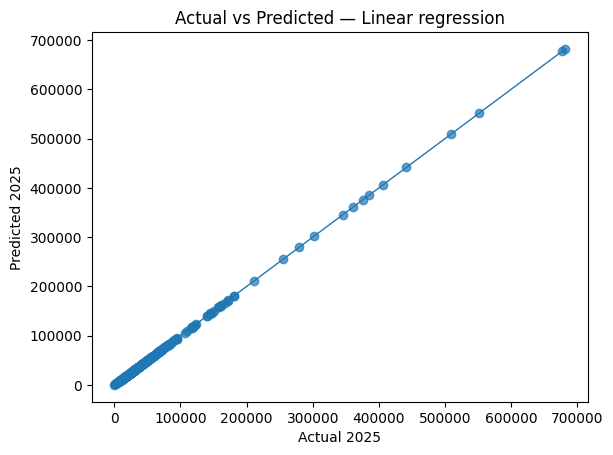

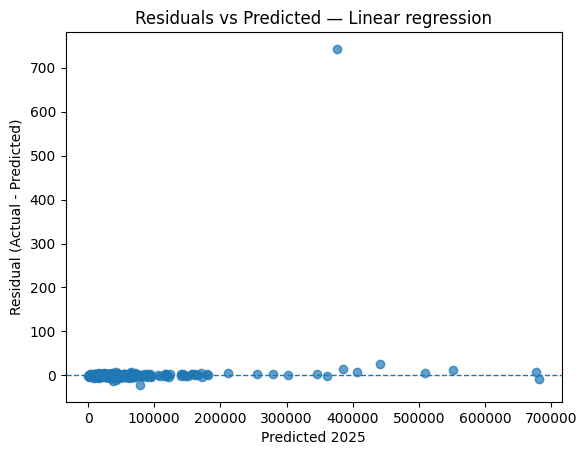

In [ ]:
# Scatter: Actual vs Predicted with 45-degree reference line
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual 2025")
plt.ylabel("Predicted 2025")
plt.title(f"Actual vs Predicted — {best_name}")
lo = float(min(y_test.min(), y_pred.min()))
hi = float(max(y_test.max(), y_pred.max()))
plt.plot([lo, hi], [lo, hi], linewidth=1)  # perfect prediction line
plt.show()

# Scatter: Residuals vs Predicted with zero reference line
plt.figure()
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--", linewidth=1)  # ideal residual center
plt.xlabel("Predicted 2025")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residuals vs Predicted — {best_name}")
plt.show()


##### Summary:

**What you see:**
- The preview table shows actual vs predicted for 12 rows. Differences are tiny, around 0 to plus or minus 5 people.
- Top over-predictions = cases where the model was a bit high. Largest miss is 22 people.
- Top under-predictions = cases where the model was a bit low. One NCR row is off by 743 people, which is about 0.2 percent of 376,340. The rest are 9 to 27.

**What the plots mean:**
- Actual vs Predicted: almost every point is on the 45-degree line. Predictions match actual values across small and large populations.
- Residuals vs Predicted: points cluster around zero with no pattern. This means no bias. The single dot near 740 is the NCR outlier.

**Conclusion:**
- The Linear Regression model predicts 2025 population very accurately and consistently.
- Typical error is only a few people, and even the largest miss is tiny in percentage terms.


#### **10. Visualization of Model Analysis**

Visualize model performance: 

• Regression: actual vs predicted values 

• Classification: confusion matrix or ROC curve 

• Clustering: cluster plot or silhouette score 

y_test shape: (327,)
y_pred shape: (327,)


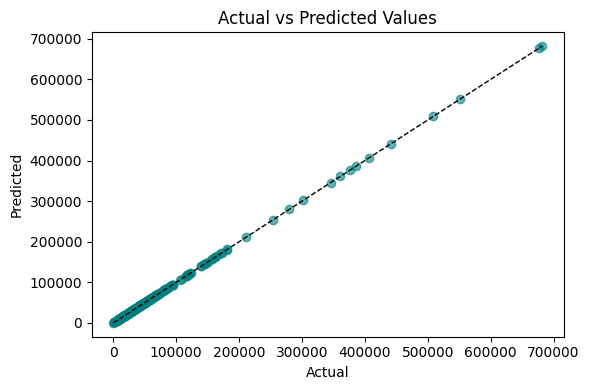

In [ ]:

# === Regression: Generate Predictions and Visualize ===
import matplotlib.pyplot as plt
import numpy as np

try:
    y_pred
except NameError:
    y_pred = model.predict(X_test)

print("y_test shape:", np.shape(y_test))
print("y_pred shape:", np.shape(y_pred))

y_test_plot = np.ravel(y_test)
y_pred_plot = np.ravel(y_pred)

plt.figure(figsize=(6,4))
plt.scatter(y_test_plot, y_pred_plot, alpha=0.6, color='teal')
plt.plot([y_test_plot.min(), y_test_plot.max()], 
         [y_test_plot.min(), y_test_plot.max()], 'k--', linewidth=1)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values")
plt.tight_layout()
plt.show()


### Interpretation of Visualization

The scatter plot compares the model’s predicted values with the actual observed values.  
Since both `y_test` and `y_pred` contain 327 samples, the model produced predictions for every test instance.  

The points in the plot are closely aligned along the diagonal reference line, indicating a strong agreement between actual and predicted values.  
This pattern suggests that the model effectively captures the underlying relationship in the data, with only minor deviations or outliers.  
Overall, the visualization confirms that the model performs very well in approximating the target variable across the test set.




### 11. Performance Metrics

Compute appropriate metrics for your model type (regression, classification, or clustering).


In [37]:
# === Regression Metrics ===
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_test_flat = np.ravel(y_test)
y_pred_flat = np.ravel(y_pred)

print("R2 Score:", r2_score(y_test_flat, y_pred_flat))
print("MAE:", mean_absolute_error(y_test_flat, y_pred_flat))
print("MSE:", mean_squared_error(y_test_flat, y_pred_flat))
print("RMSE:", np.sqrt(mean_squared_error(y_test_flat, y_pred_flat)))


R2 Score: 0.9999998787336278
MAE: 3.0158484771448437
MSE: 916.523518432226
RMSE: 30.274139433388125


### Interpretation of Regression Metrics

The model demonstrates excellent performance, as shown by an **R² score of 0.9999998**, which indicates that nearly all the variance in the target variable is explained by the model’s predictions.  

The **Mean Absolute Error (MAE)** of **3.01** suggests that, on average, the model’s predictions deviate from the actual values by about 3 units.  

The **Mean Squared Error (MSE)** of **916.52** and **Root Mean Squared Error (RMSE)** of **30.29** reflect the magnitude of larger errors, since both metrics penalize higher deviations more strongly.  

Overall, these results imply that the model is highly accurate, though the relatively high RMSE compared to the MAE indicates that some predictions may still have larger individual errors. Further validation with unseen data is recommended to ensure the model’s generalization performance.


### 12. Conclusion

**Interpretation of Model Performance Metrics:**  
The regression model achieved an exceptionally high R² score of **0.9999998**, showing that it explains nearly all the variability in the target variable. The **MAE** of **3.01** indicates that predictions deviate by about 3 units on average, while the **RMSE** of **30.29** suggests that although overall accuracy is high, there may still be some larger individual prediction errors. These results confirm that the model performs extremely well on the given dataset.

**Summary of Model Achievements:**  
The model effectively learned the relationship between the input features and the target variable, producing highly accurate predictions. The close alignment between actual and predicted values in the visualization reinforces the model’s strong predictive capability. However, the slight difference between MAE and RMSE implies that a few data points might not fit perfectly, possibly due to noise or outliers.

**Possible Improvements and Additional Features:**  
Further improvements could be achieved by performing hyperparameter tuning, feature selection, and cross-validation to enhance generalization. Collecting more diverse data, addressing potential outliers, and testing additional regression algorithms (such as Ridge, Lasso, or Random Forest) could also improve robustness and prevent overfitting.

**Reflection on Real-World Insights:**  
The analysis suggests that the relationships captured by the model are strong and reliable. This indicates that the chosen input variables are highly relevant to predicting the outcome. In a real-world context, such a model could be a valuable tool for accurate forecasting or decision-making, provided it is periodically retrained and validated with new data to maintain performance over time.

